<a href="https://colab.research.google.com/github/BPerkins98/homework/blob/main/Homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C:\Users\perki\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\perki\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\perki\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\perki\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\perki\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

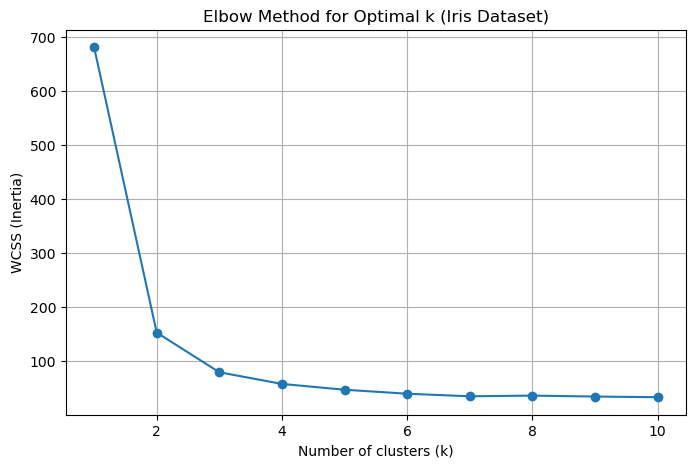

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
X = iris.data

# Compute WCSS (inertia) for k = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=11)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal k (Iris Dataset)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()


In [ ]:
import time
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target
print("Dataset loaded successfully.\n")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

# Standardize features
print("Applying StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.\n")

# -------------------------------
# Logistic Regression WITHOUT PCA
# -------------------------------
print("Training Logistic Regression WITHOUT PCA...")
start_no_pca = time.time()

log_reg_no_pca = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg_no_pca.fit(X_train_scaled, y_train)

end_no_pca = time.time()
print("Training complete.\n")

y_pred_no_pca = log_reg_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

# -------------------------------
# Logistic Regression WITH PCA
# -------------------------------
print("Applying PCA (retain 95% variance)...")
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("PCA complete.\n")

print("Training Logistic Regression WITH PCA...")
start_pca = time.time()

log_reg_pca = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg_pca.fit(X_train_pca, y_train)

end_pca = time.time()
print("Training complete.\n")

y_pred_pca = log_reg_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

# -------------------------------
# Results
# -------------------------------
print("WITHOUT PCA:")
print("Accuracy:", acc_no_pca)
print("Time:", round(end_no_pca - start_no_pca, 2), "seconds")

print("\nWITH PCA (95% variance):")
print("Accuracy:", acc_pca)
print("Time:", round(end_pca - start_pca, 2), "seconds")

print("\nNumber of PCA components:", pca.n_components_)


Loading MNIST dataset...
Dataset loaded successfully.

Applying StandardScaler...
Scaling complete.

Training Logistic Regression WITHOUT PCA...
Training complete.

Applying PCA (retain 95% variance)...
PCA complete.

Training Logistic Regression WITH PCA...
Training complete.

WITHOUT PCA:
Accuracy: 0.9136428571428571
Time: 28.03 seconds

WITH PCA (95% variance):
Accuracy: 0.9215
Time: 14.4 seconds

Number of PCA components: 328
